In [92]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
!pip install torchmetrics

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import nltk
import numpy as np

from torchmetrics.regression import SpearmanCorrCoef
from numpy.linalg import norm
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [96]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [97]:
# Load the data
df = pd.read_excel("/content/drive/Shareddrives/group5_P2.2/group5_data/all_data.xlsx")

num_rows = df.shape[0]
num_cols = df.shape[1]

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 226
Number of columns: 53


/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [98]:
# Drop the first two columns (Participant # and Group #)
dropped_columns = ['Participant #', 'Group #']
df = df.drop(dropped_columns, axis=1)
df.head()

,The cyber-attacker accessed your computer files.,The cyber-attacker accessed your computer programs.,The cyber-attacker accessed your information stored in an Internet site.,The cyber-attacker caused a program on your computer to crash.,The cyber-attacker caused your computer program to run very slowly.,The cyber-attacker caused your computer to crash.,The cyber-attacker caused your computer to run very slowly.,The cyber-attacker caused your Internet connection to run very slowly.,The cyber-attacker caused your request for a certain Internet page to actually take you to a different Internet page.,The cyber-attacker changed a device’s serial number.,...,The cyber-attacker prevented you from using your computer until you pay a ransom.,The cyber-attacker removed your computer files in order to hide their activities.,The cyber-attacker rerouted your Internet requests to a device that they control.,The cyber-attacker saw what was presented on your computer screen.,The cyber-attacker sent you an email that asks you to click on a given Internet link.,The cyber-attacker sent you an email that asks you to respond with certain personal information.,The cyber-attacker shut down an Internet site that you were using.,The cyber-attacker took control over one of your financial accounts.,The cyber-attacker used your computer to store and distribute stolen software.,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,NaN
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,NaN


In [99]:
# Reshape the data for more clarity
new_df = df.transpose()

new_df.reset_index(names='Attack Consequences', inplace=True)
new_df = new_df[:-1]
new_df.head()

,Attack Consequences,0,1,2,3,4,5,6,7,8,...,216,217,218,219,220,221,222,223,224,225
0,The cyber-attacker accessed your computer files.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,The cyber-attacker accessed your computer prog...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,The cyber-attacker accessed your information s...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,The cyber-attacker caused a program on your co...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,The cyber-attacker caused your computer progra...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Step 1: Human-Based Similarity Matrix (Given Vectors)**

/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


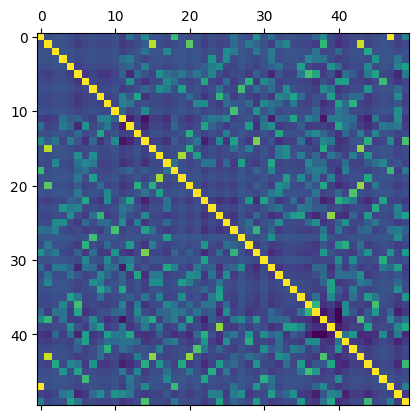

In [100]:
# Create a matrix containing pairwise similarities between the provided document vectors
spearman_matrix = []
num_rows = new_df.shape[0]
num_cols = new_df.shape[0]

for i in range(num_rows):
  row = []
  curr_row = torch.tensor(new_df[i].values[1:])

  for j in range(num_cols):
    curr_col = torch.tensor(new_df[j].values[1:])
    spearman = SpearmanCorrCoef()

    similarity = spearman(curr_row, curr_col)
    row.append(similarity)

  spearman_matrix.append(row)

plt.matshow(spearman_matrix)
plt.show()

**Step 2: NLP Vectorization (BOW & TF-IDF)**

In [101]:
# Define a function that removes stop words
def remove_stop_words(text):
  tokens = word_tokenize(text.lower())

  stop_words = set(stopwords.words('english'))
  filtered_tokens = [word for word in tokens if word not in stop_words]

  clean_text = [
      word for word in filtered_tokens
      if word.isalnum()
  ]

  return ' '.join(clean_text)

In [102]:
# Define a function that applies stemming
def apply_stemming(text):
  ps = PorterStemmer()
  words = word_tokenize(text)

  stemmed_words = []
  for w in words:
    stemmed_words.append(ps.stem(w))

  return ' '.join(stemmed_words)

In [103]:
# Define a function that generates a particular configuration
def generate_configuration(text, sw, stem):
  if (sw == True):
    res = remove_stop_words(text)
  else:
    res = text

  if (stem == True):
    res = apply_stemming(res)
  else:
    res = text

  return res

In [129]:
# Generate a BOW matrix for a particular configuration
def generate_bow_matrix(n, documents):
  cosine_matrix = []

  # Apply BOW (Bag of Words) vectorization
  vectorizer = CountVectorizer(ngram_range=(n, n))
  vector = vectorizer.fit_transform(documents)
  vector_matrix = vector.toarray()

  for i in vector_matrix:
    matrix_row = []

    for j in vector_matrix:
      cosine_similarity = np.dot(i, j) / (norm(i) * norm(j))
      matrix_row.append(cosine_similarity)

  cosine_matrix.append(matrix_row)

  return cosine_matrix

In [130]:
# Generate a TF-IDF matrix for a particular configuration
def generate_tfidf_matrix(n, documents):
  cosine_matrix = []

  # Apply TFIDF vectorization
  tfidf = TfidfVectorizer(ngram_range=(n, n))
  tfidf_vector = tfidf.fit_transform(documents)
  vector_matrix = tfidf_vector.toarray()

  for i in vector_matrix:
    matrix_row = []

    for j in vector_matrix:
      cosine_similarity = np.dot(i, j) / (norm(i) * norm(j))
      matrix_row.append(cosine_similarity)

  cosine_matrix.append(matrix_row)

  return cosine_matrix

In [131]:
def save_matrix(matrix, title, file_name):
  plt.figure()
  plt.matshow(matrix)
  plt.title(title)
  plt.savefig(file_name)

<Figure size 640x480 with 0 Axes>

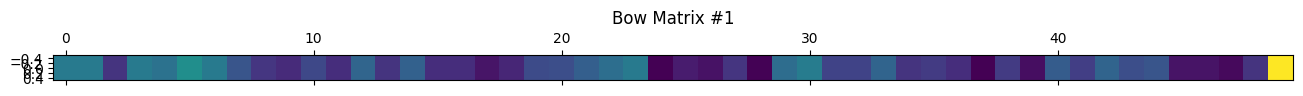

<Figure size 640x480 with 0 Axes>

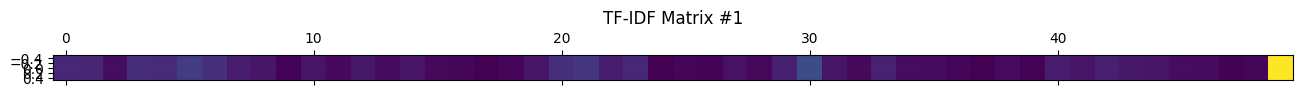

<Figure size 640x480 with 0 Axes>

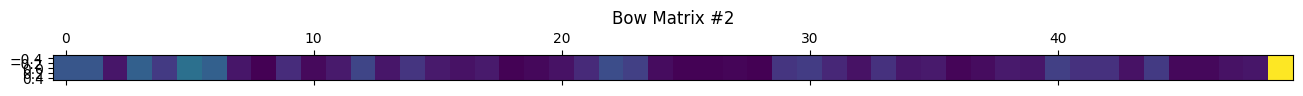

<Figure size 640x480 with 0 Axes>

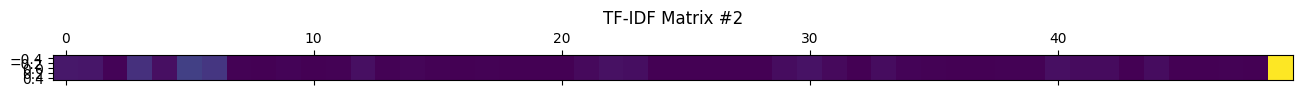

<Figure size 640x480 with 0 Axes>

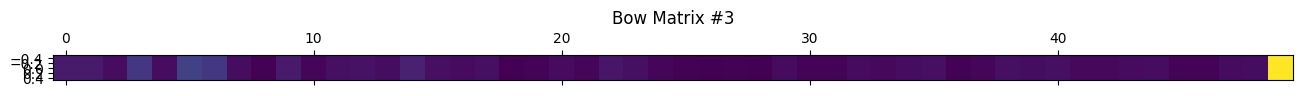

<Figure size 640x480 with 0 Axes>

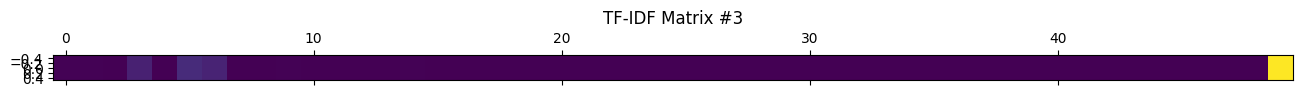

In [134]:
# Configuration #1-3: No stop words removal, no stemming, (unigram, bigram, trigram)
docs = new_df['Attack Consequences'].values

bow_matrix_1 = generate_bow_matrix(1, docs)
tfidf_matrix_1 = generate_tfidf_matrix(1, docs)

save_matrix(bow_matrix_1, "Bow Matrix #1", "bow_matrix_1.png")
save_matrix(tfidf_matrix_1, "TF-IDF Matrix #1", "tfidf_matrix_1.png")

bow_matrix_2 = generate_bow_matrix(2, docs)
tfidf_matrix_2 = generate_tfidf_matrix(2, docs)

save_matrix(bow_matrix_2, "Bow Matrix #2", "bow_matrix_2.png")
save_matrix(tfidf_matrix_2, "TF-IDF Matrix #2", "tfidf_matrix_2.png")

bow_matrix_3 = generate_bow_matrix(3, docs)
tfidf_matrix_3 = generate_tfidf_matrix(3, docs)

save_matrix(bow_matrix_3, "Bow Matrix #3", "bow_matrix_3.png")
save_matrix(tfidf_matrix_3, "TF-IDF Matrix #3", "tfidf_matrix_3.png")